# Week 4 — GLCM & Gabor Baseline Texture Descriptors
Adds GLCM (Haralick) and Gabor filter-bank descriptors on the same patch dataset and window scale as Week 3's LBP baseline, builds a combined GLCM+Gabor feature, and compares all four descriptors on the same validation sample to pick a single-scale baseline.

**SETUP**  
Mount Drive and import libraries.

In [20]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import random

from skimage.feature import local_binary_pattern
from skimage.filters import threshold_otsu

try:
    from skimage.feature import graycomatrix, graycoprops
except ImportError:
    from skimage.feature import greycomatrix as graycomatrix, greycoprops as graycoprops


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**LOAD WEEK 2 PATCH DATASET**  
Same patch folders used in Week 3 — no re-processing here.

In [ ]:
PATCHED_DIR = Path("/content/drive/MyDrive/ECE501/processed_patches")

PATCH_IMAGE_DIR = PATCHED_DIR / "images"
PATCH_MASK_DIR = PATCHED_DIR / "masks"
NODEFECT_PATCH_DIR = PATCHED_DIR / "nodefect_images"

defect_patch_files = sorted(PATCH_IMAGE_DIR.glob("*.png"))
nodefect_patch_files = sorted(NODEFECT_PATCH_DIR.glob("*.png"))

print("=" * 60)
print("PATCH DATASET LOADED")
print("=" * 60)

print(f"Defect patches       : {len(defect_patch_files)}")
print(f"Defect-free patches  : {len(nodefect_patch_files)}")


PATCH DATASET LOADED
Defect patches       : 3222
Defect-free patches  : 4371


**FABRIC TYPE FROM FILENAME**  
Same rule as Week 2/3 — fabric type is the numeric prefix before the first underscore.

In [ ]:
def get_fabric_type(stem):
    parts = stem.split("_")
    return parts[2] if len(parts) >= 3 else "unknown"


In [ ]:
defect_fabrics = {get_fabric_type(f.stem) for f in defect_patch_files}
nodefect_fabrics = {get_fabric_type(f.stem) for f in nodefect_patch_files}
print("Defect fabric codes      :", sorted(defect_fabrics))
print("Defect-free fabric codes :", sorted(nodefect_fabrics))
print("No defect-free reference :", sorted(defect_fabrics - nodefect_fabrics))

Defect fabric codes      : ['00', '01', '02', '03', '04', '05', '06']
Defect-free fabric codes : ['00', '01', '02', '03', '04', '05', '06']
No defect-free reference : []


**SHARED SETTINGS**  
Window size, blank-window filter, and evaluation helpers used by every descriptor so the comparison is at a fixed, common scale.

In [ ]:
WINDOW_SIZE = 32
WINDOW_STRIDE = 16
VARIANCE_THRESHOLD = 5.0  # skip flat/blank windows (background/border) when building references

def deviation_map_to_mask(deviation_map):
    norm_map = (deviation_map - deviation_map.min()) / (deviation_map.max() - deviation_map.min() + 1e-10)
    norm_map_uint8 = (norm_map * 255).astype(np.uint8)

    try:
        thresh = threshold_otsu(norm_map_uint8)
    except ValueError:
        thresh = 128

    binary_mask = (norm_map_uint8 > thresh).astype(np.uint8) * 255
    return binary_mask, norm_map

def confidence_score(deviation_map, binary_mask):
    if np.count_nonzero(binary_mask) == 0:
        return 0.0

    region_vals = deviation_map[binary_mask > 0]
    background_vals = deviation_map[binary_mask == 0]

    if len(background_vals) == 0:
        return 0.0

    return float((region_vals.mean() - background_vals.mean()) / (background_vals.std() + 1e-10))

def compute_metrics(pred_mask, gt_mask):
    pred = pred_mask > 0
    gt = gt_mask > 0

    tp = np.logical_and(pred, gt).sum()
    fp = np.logical_and(pred, np.logical_not(gt)).sum()
    fn = np.logical_and(np.logical_not(pred), gt).sum()

    iou = tp / (tp + fp + fn + 1e-10)
    precision = tp / (tp + fp + 1e-10)
    recall = tp / (tp + fn + 1e-10)
    f1 = 2 * precision * recall / (precision + recall + 1e-10)

    return {"IoU": iou, "Precision": precision, "Recall": recall, "F1": f1}


**LBP (WEEK 3 BASELINE, REUSED)**  
Same multi-radius uniform LBP + chi-square distance, included here so all descriptors can be compared in one notebook.

In [ ]:
LBP_RADII = [1, 2, 3]
LBP_METHOD = "uniform"

def lbp_histogram(gray_patch, radii=LBP_RADII, method=LBP_METHOD):
    hist_all = []
    for radius in radii:
        n_points = 8 * radius
        lbp = local_binary_pattern(gray_patch, n_points, radius, method)
        n_bins = n_points + 2
        hist, _ = np.histogram(lbp.ravel(), bins=n_bins, range=(0, n_bins), density=True)
        hist_all.append(hist)
    return np.concatenate(hist_all)

def chi_square_distance(hist1, hist2, eps=1e-10):
    return 0.5 * np.sum(((hist1 - hist2) ** 2) / (hist1 + hist2 + eps))

def build_lbp_reference(files):
    fabric_sum, fabric_count, skipped = {}, {}, 0

    for file in files:
        fabric_type = get_fabric_type(file.stem)
        gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        h, w = gray.shape

        for y in range(0, h - WINDOW_SIZE + 1, WINDOW_SIZE):
            for x in range(0, w - WINDOW_SIZE + 1, WINDOW_SIZE):
                window = gray[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
                if window.std() < VARIANCE_THRESHOLD:
                    skipped += 1
                    continue
                hist = lbp_histogram(window)
                fabric_sum.setdefault(fabric_type, np.zeros_like(hist))
                fabric_count[fabric_type] = fabric_count.get(fabric_type, 0) + 1
                fabric_sum[fabric_type] += hist

    reference = {ft: fabric_sum[ft] / fabric_count[ft] for ft in fabric_sum}
    global_ref = np.mean(list(reference.values()), axis=0)
    return reference, global_ref, skipped

def compute_deviation_map_lbp(gray_patch, reference_hist):
    h, w = gray_patch.shape
    deviation_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h - WINDOW_SIZE + 1, WINDOW_STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, WINDOW_STRIDE):
            window = gray_patch[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
            hist = lbp_histogram(window)
            score = chi_square_distance(hist, reference_hist)
            deviation_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += score
            count_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += 1

    count_map[count_map == 0] = 1
    return deviation_map / count_map

lbp_reference, lbp_global_reference, lbp_skipped = build_lbp_reference(nodefect_patch_files)

print("LBP reference built for", len(lbp_reference), "fabric types")
print(f"Blank/flat windows skipped (std < {VARIANCE_THRESHOLD}): {lbp_skipped}")


LBP reference built for 7 fabric types
Blank/flat windows skipped (std < 5.0): 27317


**GLCM (HARALICK) FEATURES**  
Contrast, energy, homogeneity, and correlation, averaged over 4 angles at distance 1, on 8 gray levels per window.

In [ ]:
GRAY_LEVELS = 8
GLCM_DISTANCES = [1]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPS = ["contrast", "energy", "homogeneity", "correlation"]

def quantize(gray_window, levels=GRAY_LEVELS):
    return (gray_window.astype(np.float64) / 256 * levels).astype(np.uint8).clip(0, levels - 1)

def glcm_features(gray_window):
    q = quantize(gray_window)
    glcm = graycomatrix(
        q, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
        levels=GRAY_LEVELS, symmetric=True, normed=True
    )
    feats = [graycoprops(glcm, prop).mean() for prop in GLCM_PROPS]
    return np.nan_to_num(np.array(feats), nan=0.0, posinf=0.0, neginf=0.0)

def standardized_distance(feat, ref_mean, ref_std, eps=1e-6):
    z = (feat - ref_mean) / (ref_std + eps)
    return float(np.sqrt(np.sum(z ** 2)))

def build_glcm_reference(files):
    fabric_feats, skipped = {}, 0

    for file in files:
        fabric_type = get_fabric_type(file.stem)
        gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        h, w = gray.shape

        for y in range(0, h - WINDOW_SIZE + 1, WINDOW_SIZE):
            for x in range(0, w - WINDOW_SIZE + 1, WINDOW_SIZE):
                window = gray[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
                if window.std() < VARIANCE_THRESHOLD:
                    skipped += 1
                    continue
                feats = glcm_features(window)
                fabric_feats.setdefault(fabric_type, []).append(feats)

    reference = {}
    for ft, feats in fabric_feats.items():
        arr = np.array(feats)
        reference[ft] = (arr.mean(axis=0), arr.std(axis=0))

    all_feats = np.concatenate([np.array(v) for v in fabric_feats.values()], axis=0)
    global_ref = (all_feats.mean(axis=0), all_feats.std(axis=0))
    return reference, global_ref, skipped

def compute_deviation_map_glcm(gray_patch, reference):
    ref_mean, ref_std = reference
    h, w = gray_patch.shape
    deviation_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)

    for y in range(0, h - WINDOW_SIZE + 1, WINDOW_STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, WINDOW_STRIDE):
            window = gray_patch[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
            feats = glcm_features(window)
            score = standardized_distance(feats, ref_mean, ref_std)
            deviation_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += score
            count_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += 1

    count_map[count_map == 0] = 1
    return deviation_map / count_map

glcm_reference, glcm_global_reference, glcm_skipped = build_glcm_reference(nodefect_patch_files)

print("GLCM reference built for", len(glcm_reference), "fabric types")
print(f"Blank/flat windows skipped (std < {VARIANCE_THRESHOLD}): {glcm_skipped}")


GLCM reference built for 7 fabric types
Blank/flat windows skipped (std < 5.0): 27317


**GABOR FILTER BANK**  
4 orientations x 3 frequencies, filtered once per patch, then averaged per window for a fast energy-like feature.

In [ ]:
GABOR_THETAS = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GABOR_FREQS = [0.1, 0.25, 0.4]
GABOR_KSIZE = 15

def build_gabor_bank():
    kernels = []
    for theta in GABOR_THETAS:
        for freq in GABOR_FREQS:
            kernel = cv2.getGaborKernel(
                (GABOR_KSIZE, GABOR_KSIZE), sigma=4.0, theta=theta,
                lambd=1.0 / freq, gamma=0.5, psi=0, ktype=cv2.CV_32F
            )
            kernels.append(kernel)
    return kernels

GABOR_KERNELS = build_gabor_bank()

def gabor_response_maps(gray_patch, kernels=GABOR_KERNELS):
    gray_f = gray_patch.astype(np.float32)
    return [cv2.filter2D(gray_f, cv2.CV_32F, k) for k in kernels]

def gabor_window_features(response_maps, y, x, window_size=WINDOW_SIZE):
    feats = [np.mean(np.abs(resp[y:y + window_size, x:x + window_size])) for resp in response_maps]
    return np.nan_to_num(np.array(feats), nan=0.0, posinf=0.0, neginf=0.0)

def build_gabor_reference(files):
    fabric_feats, skipped = {}, 0

    for file in files:
        fabric_type = get_fabric_type(file.stem)
        gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        h, w = gray.shape
        response_maps = gabor_response_maps(gray)

        for y in range(0, h - WINDOW_SIZE + 1, WINDOW_SIZE):
            for x in range(0, w - WINDOW_SIZE + 1, WINDOW_SIZE):
                window = gray[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
                if window.std() < VARIANCE_THRESHOLD:
                    skipped += 1
                    continue
                feats = gabor_window_features(response_maps, y, x)
                fabric_feats.setdefault(fabric_type, []).append(feats)

    reference = {}
    for ft, feats in fabric_feats.items():
        arr = np.array(feats)
        reference[ft] = (arr.mean(axis=0), arr.std(axis=0))

    all_feats = np.concatenate([np.array(v) for v in fabric_feats.values()], axis=0)
    global_ref = (all_feats.mean(axis=0), all_feats.std(axis=0))
    return reference, global_ref, skipped

def compute_deviation_map_gabor(gray_patch, reference):
    ref_mean, ref_std = reference
    h, w = gray_patch.shape
    deviation_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)
    response_maps = gabor_response_maps(gray_patch)

    for y in range(0, h - WINDOW_SIZE + 1, WINDOW_STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, WINDOW_STRIDE):
            feats = gabor_window_features(response_maps, y, x)
            score = standardized_distance(feats, ref_mean, ref_std)
            deviation_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += score
            count_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += 1

    count_map[count_map == 0] = 1
    return deviation_map / count_map

gabor_reference, gabor_global_reference, gabor_skipped = build_gabor_reference(nodefect_patch_files)

print("Gabor reference built for", len(gabor_reference), "fabric types")
print(f"Blank/flat windows skipped (std < {VARIANCE_THRESHOLD}): {gabor_skipped}")


Gabor reference built for 7 fabric types
Blank/flat windows skipped (std < 5.0): 27317


**COMBINED GLCM + GABOR**  
Concatenates the GLCM and Gabor feature vectors for the same window into one combined descriptor.

In [ ]:
def combined_features(gray_window, response_maps, y, x):
    glcm_feats = glcm_features(gray_window)
    gabor_feats = gabor_window_features(response_maps, y, x)
    return np.concatenate([glcm_feats, gabor_feats])

def build_combined_reference(files):
    fabric_feats, skipped = {}, 0

    for file in files:
        fabric_type = get_fabric_type(file.stem)
        gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
        if gray is None:
            continue
        h, w = gray.shape
        response_maps = gabor_response_maps(gray)

        for y in range(0, h - WINDOW_SIZE + 1, WINDOW_SIZE):
            for x in range(0, w - WINDOW_SIZE + 1, WINDOW_SIZE):
                window = gray[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
                if window.std() < VARIANCE_THRESHOLD:
                    skipped += 1
                    continue
                feats = combined_features(window, response_maps, y, x)
                fabric_feats.setdefault(fabric_type, []).append(feats)

    reference = {}
    for ft, feats in fabric_feats.items():
        arr = np.array(feats)
        reference[ft] = (arr.mean(axis=0), arr.std(axis=0))

    all_feats = np.concatenate([np.array(v) for v in fabric_feats.values()], axis=0)
    global_ref = (all_feats.mean(axis=0), all_feats.std(axis=0))
    return reference, global_ref, skipped

def compute_deviation_map_combined(gray_patch, reference):
    ref_mean, ref_std = reference
    h, w = gray_patch.shape
    deviation_map = np.zeros((h, w), dtype=np.float32)
    count_map = np.zeros((h, w), dtype=np.float32)
    response_maps = gabor_response_maps(gray_patch)

    for y in range(0, h - WINDOW_SIZE + 1, WINDOW_STRIDE):
        for x in range(0, w - WINDOW_SIZE + 1, WINDOW_STRIDE):
            window = gray_patch[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE]
            feats = combined_features(window, response_maps, y, x)
            score = standardized_distance(feats, ref_mean, ref_std)
            deviation_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += score
            count_map[y:y + WINDOW_SIZE, x:x + WINDOW_SIZE] += 1

    count_map[count_map == 0] = 1
    return deviation_map / count_map

combined_reference, combined_global_reference, combined_skipped = build_combined_reference(nodefect_patch_files)

print("Combined GLCM+Gabor reference built for", len(combined_reference), "fabric types")
print(f"Blank/flat windows skipped (std < {VARIANCE_THRESHOLD}): {combined_skipped}")


Combined GLCM+Gabor reference built for 7 fabric types
Blank/flat windows skipped (std < 5.0): 27317


**VALIDATION SAMPLE**  
Same random, seeded sample of defect-containing patches used for every descriptor, so the comparison is fair.

In [21]:
random.seed(42)
N_SAMPLES = 10

candidate_patches = []
for file in defect_patch_files:
    mask_path = PATCH_MASK_DIR / file.name
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if mask is not None and np.count_nonzero(mask) > 0:
        candidate_patches.append(file)

N_SAMPLES = min(N_SAMPLES, len(candidate_patches))
sample_patches = sorted(random.sample(candidate_patches, N_SAMPLES))

print(f"Validation sample: {len(sample_patches)} defect-containing patches")


Validation sample: 10 defect-containing patches


**RUN ALL DESCRIPTORS ON THE SAME SAMPLE**  
LBP, GLCM, Gabor, and combined GLCM+Gabor, each scored and thresholded the same way (Otsu, fixed window/stride).

In [ ]:
def run_descriptor(file, descriptor):
    gray = cv2.imread(str(file), cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.imread(str(PATCH_MASK_DIR / file.name), cv2.IMREAD_GRAYSCALE)
    fabric_type = get_fabric_type(file.stem)

    if descriptor == "LBP":
        reference = lbp_reference.get(fabric_type, lbp_global_reference)
        deviation_map = compute_deviation_map_lbp(gray, reference)
    elif descriptor == "GLCM":
        reference = glcm_reference.get(fabric_type, glcm_global_reference)
        deviation_map = compute_deviation_map_glcm(gray, reference)
    elif descriptor == "Gabor":
        reference = gabor_reference.get(fabric_type, gabor_global_reference)
        deviation_map = compute_deviation_map_gabor(gray, reference)
    elif descriptor == "GLCM+Gabor":
        reference = combined_reference.get(fabric_type, combined_global_reference)
        deviation_map = compute_deviation_map_combined(gray, reference)
    else:
        raise ValueError(f"Unknown descriptor: {descriptor}")

    pred_mask, norm_map = deviation_map_to_mask(deviation_map)
    confidence = confidence_score(deviation_map, pred_mask)
    metrics = compute_metrics(pred_mask, gt_mask)

    return deviation_map, norm_map, pred_mask, confidence, metrics

DESCRIPTORS = ["LBP", "GLCM", "Gabor", "GLCM+Gabor"]
results = []

for file in sample_patches:
    fabric_type = get_fabric_type(file.stem)
    for descriptor in DESCRIPTORS:
        _, _, _, confidence, metrics = run_descriptor(file, descriptor)
        results.append({
            "file": file.name,
            "fabric_type": fabric_type,
            "descriptor": descriptor,
            "confidence": confidence,
            **metrics
        })

results_df = pd.DataFrame(results)

print("=" * 60)
print("PER-PATCH RESULTS")
print("=" * 60)

print(results_df.round(3).to_string(index=False))


PER-PATCH RESULTS
                    file fabric_type descriptor  confidence   IoU  Precision  Recall    F1
0010_006_02_x2944_y0.png          02        LBP      13.010 0.616      0.643   0.937 0.762
0010_006_02_x2944_y0.png          02       GLCM       8.303 0.343      0.343   1.000 0.511
0010_006_02_x2944_y0.png          02      Gabor       5.828 0.063      0.063   0.964 0.118
0010_006_02_x2944_y0.png          02 GLCM+Gabor       5.846 0.063      0.063   0.966 0.118
0023_019_02_x1920_y0.png          02        LBP       3.867 0.000      0.000   0.000 0.000
0023_019_02_x1920_y0.png          02       GLCM       2.613 0.001      0.001   1.000 0.002
0023_019_02_x1920_y0.png          02      Gabor       4.137 0.003      0.003   1.000 0.005
0023_019_02_x1920_y0.png          02 GLCM+Gabor       4.052 0.003      0.003   1.000 0.006
0025_019_02_x2688_y0.png          02        LBP       3.809 0.000      0.000   0.000 0.000
0025_019_02_x2688_y0.png          02       GLCM       2.681 0.000      0

**VISUALIZE ONE EXAMPLE ACROSS DESCRIPTORS**  
Same patch, predicted mask from each descriptor, next to ground truth.

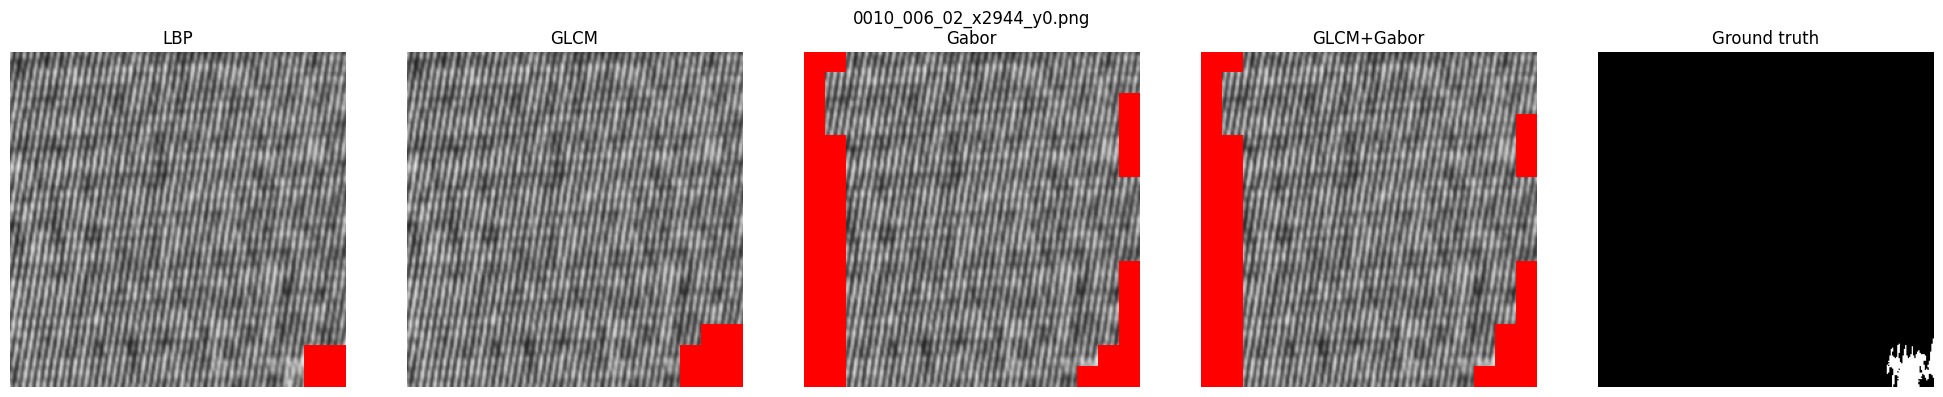

In [22]:
example_file = sample_patches[0]
gray = cv2.imread(str(example_file), cv2.IMREAD_GRAYSCALE)
gt_mask = cv2.imread(str(PATCH_MASK_DIR / example_file.name), cv2.IMREAD_GRAYSCALE)

fig, axes = plt.subplots(1, len(DESCRIPTORS) + 1, figsize=(4 * (len(DESCRIPTORS) + 1), 4))

for ax, descriptor in zip(axes[:-1], DESCRIPTORS):
    _, _, pred_mask, _, _ = run_descriptor(example_file, descriptor)
    overlay = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
    overlay[pred_mask > 0] = [255, 0, 0]
    ax.imshow(overlay)
    ax.set_title(descriptor)
    ax.axis("off")

axes[-1].imshow(gt_mask, cmap="gray")
axes[-1].set_title("Ground truth")
axes[-1].axis("off")

fig.suptitle(example_file.name)
plt.tight_layout()
plt.show()


**COMPARISON TABLE**  
Average metrics per descriptor, and the one with the highest average F1 is picked as the single-scale baseline.

In [23]:
comparison = results_df.groupby("descriptor")[["IoU", "Precision", "Recall", "F1"]].mean()
comparison = comparison.reindex(DESCRIPTORS)

print("=" * 60)
print("DESCRIPTOR COMPARISON (fixed scale, same validation sample)")
print("=" * 60)

print(comparison.round(3).to_string())

best_descriptor = comparison["F1"].idxmax()

print(f"\nBest single-scale baseline (highest average F1): {best_descriptor}")


DESCRIPTOR COMPARISON (fixed scale, same validation sample)
              IoU  Precision  Recall     F1
descriptor                                 
LBP         0.104      0.111   0.175  0.136
GLCM        0.043      0.044   0.656  0.068
Gabor       0.064      0.065   0.592  0.085
GLCM+Gabor  0.064      0.066   0.692  0.086

Best single-scale baseline (highest average F1): LBP


**WEEK 4 SUMMARY**  
Parameters used and what carries forward to Week 5.

In [ ]:
print("=" * 60)
print("WEEK 4 SUMMARY")
print("=" * 60)

print(f"\nValidation sample size : {len(sample_patches)} patches")
print(f"Window / stride        : {WINDOW_SIZE}x{WINDOW_SIZE}, stride {WINDOW_STRIDE}")
print(f"Threshold method       : Otsu (same for all descriptors)")
print(f"GLCM levels / angles   : {GRAY_LEVELS} levels, {len(GLCM_ANGLES)} angles")
print(f"Gabor bank             : {len(GABOR_THETAS)} orientations x {len(GABOR_FREQS)} frequencies")

print("\nAverage metrics by descriptor:")
print(comparison.round(3).to_string())

print(f"\nChosen single-scale baseline for Week 5: {best_descriptor}")
print("Note: all descriptors share the same fixed window size and Otsu threshold here —")
print("Week 5 introduces multi-scale and adaptive parameters on top of this baseline.")


WEEK 4 SUMMARY

Validation sample size : 10 patches
Window / stride        : 32x32, stride 16
Threshold method       : Otsu (same for all descriptors)
GLCM levels / angles   : 8 levels, 4 angles
Gabor bank             : 4 orientations x 3 frequencies

Average metrics by descriptor:
              IoU  Precision  Recall     F1
descriptor                                 
LBP         0.104      0.111   0.175  0.136
GLCM        0.043      0.044   0.656  0.068
Gabor       0.064      0.065   0.592  0.085
GLCM+Gabor  0.064      0.066   0.692  0.086

Chosen single-scale baseline for Week 5: LBP
Note: all descriptors share the same fixed window size and Otsu threshold here —
Week 5 introduces multi-scale and adaptive parameters on top of this baseline.
